In [2]:
# Install the Hugging Face datasets library
#!pip install datasets

# Import PyTorch core library
import torch

# Import OS module for file/path operations
import os

# Import PyTorch neural network module
import torch.nn as nn

# Import torchvision for computer vision utilities
import torchvision
import torchvision.transforms as transforms  # For data preprocessing

# Import matplotlib for plotting images/graphs
import matplotlib.pyplot as plt

# Import torchvision datasets module
import torchvision.datasets as datasets

# Import PyTorch optimizer module
import torch.optim as optim

# Import pandas for data manipulation
import pandas as pd

# Import DataLoader to handle batching and shuffling
from torch.utils.data import DataLoader

# Import transform to convert images to tensors
from torchvision.transforms import ToTensor

# Import datasets and pre-trained models from torchvision
from torchvision import datasets, models

# Import DataLoader and random_split for splitting datasets
from torch.utils.data import DataLoader, random_split

# Import Dataset class to create custom datasets
from torch.utils.data import Dataset

# Import skimage functions for image reading and resizing
from skimage import io, transform

# Import PIL Image for image manipulation
from PIL import Image

# Import Hugging Face dataset loader
from datasets import load_dataset

# Import scikit-learn metrics for evaluation
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [3]:
# Load the training split of the Alzheimer's MRI dataset from Hugging Face
brain_dataset_train = load_dataset('Falah/Alzheimer_MRI', split='train')

# Load the test split of the Alzheimer's MRI dataset from Hugging Face
brain_dataset_test = load_dataset('Falah/Alzheimer_MRI', split='test')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

In [4]:
# Define a series of image transformations: convert to 3-channel grayscale, to tensor, and normalize
image_to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert image to 3-channel grayscale
    transforms.ToTensor(),                        # Convert image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize using standard ImageNet mean
                         std=[0.229, 0.224, 0.225])   # Normalize using standard ImageNet std
])

# Apply transformations to training dataset: transform each image and keep its label
brain_dataset_train.set_transform(lambda example: {
    'image': [image_to_tensor(img) for img in example['image']],
    'label': example['label']
})

# Apply transformations to test dataset: transform each image and keep its label
brain_dataset_test.set_transform(lambda example: {
    'image': [image_to_tensor(img) for img in example['image']],
    'label': example['label']
})


# Split the training dataset into training and validation sets (80% train, 20% validation)
train_size = int(0.8 * len(brain_dataset_train))
val_size = len(brain_dataset_train) - train_size
train_dataset, val_dataset = random_split(brain_dataset_train, [train_size, val_size])
train_dataset, val_dataset = random_split(brain_dataset_train,[train_size, val_size],generator=torch.Generator().manual_seed(42)
)

# Create DataLoader for training dataset with batch size 32 and shuffling enabled
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Create DataLoader for validation dataset with batch size 32 and no shuffling
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Create DataLoader for test dataset with batch size 32 and no shuffling
test_dataloader = DataLoader(brain_dataset_test, batch_size=32, shuffle=False)

In [5]:
# Define number of output classes
num_classes = 4

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print which device is being used
print("using:", device)

# Load pre-trained EfficientNet-B7 model
model = torchvision.models.efficientnet_b7(weights='EfficientNet_B7_Weights.IMAGENET1K_V1')

# Get input features of the classifier layer
in_feature = model.classifier[1].in_features

# Replace the classifier with dropout + linear layer for our number of classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),  # Apply dropout for regularization
    nn.Linear(in_feature, num_classes)  # Final layer maps features to class scores
)

# Move model to the selected device
model.to(device)

# Define loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Define optimizer (Adam) with learning rate 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


using: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth


100%|██████████| 255M/255M [00:01<00:00, 196MB/s]


In [10]:
# Set number of training epochs
epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# -----------------------------------------
# Arrays to store ALL predictions and labels
# -----------------------------------------
all_labels = []
all_preds = []

for epoch in range(epochs):

    # --------------------------
    # Training
    # --------------------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in train_dataloader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Compute accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / len(train_dataloader)
    epoch_train_acc = correct / total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --------------------------
    # Validation
    # --------------------------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_dataloader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            # -----------------------------------------
            # Collect ALL validation labels & predictions
            # -----------------------------------------
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_val_loss = val_loss / len(val_dataloader)
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"EfficientNet_B7 Epoch {epoch+1}/{epochs}: "
          f"Train Loss={epoch_train_loss:.4f}, Train Acc={epoch_train_acc:.4f}, "
          f"Val Loss={epoch_val_loss:.4f}, Val Acc={epoch_val_acc:.4f}")

print("Training Complete for EfficientNet_B7")

# Convert to numpy arrays (optional, recommended)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)


EfficientNet_B7 Epoch 1/5: Train Loss=0.0567, Train Acc=0.9802, Val Loss=0.3170, Val Acc=0.9062
EfficientNet_B7 Epoch 2/5: Train Loss=0.0320, Train Acc=0.9905, Val Loss=0.3907, Val Acc=0.9062
EfficientNet_B7 Epoch 3/5: Train Loss=0.0366, Train Acc=0.9893, Val Loss=0.3047, Val Acc=0.9023
EfficientNet_B7 Epoch 4/5: Train Loss=0.0344, Train Acc=0.9871, Val Loss=0.1253, Val Acc=0.9717
EfficientNet_B7 Epoch 5/5: Train Loss=0.0198, Train Acc=0.9941, Val Loss=0.2223, Val Acc=0.9502
Training Complete for EfficientNet_B7


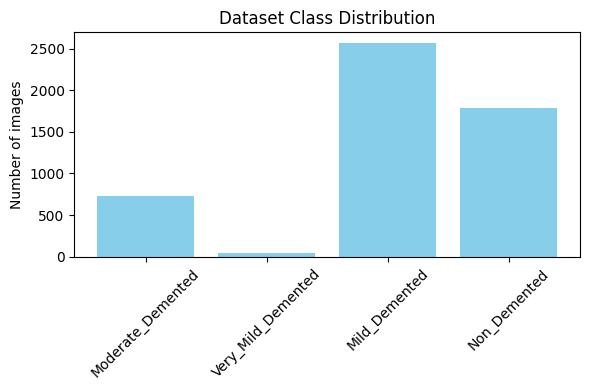

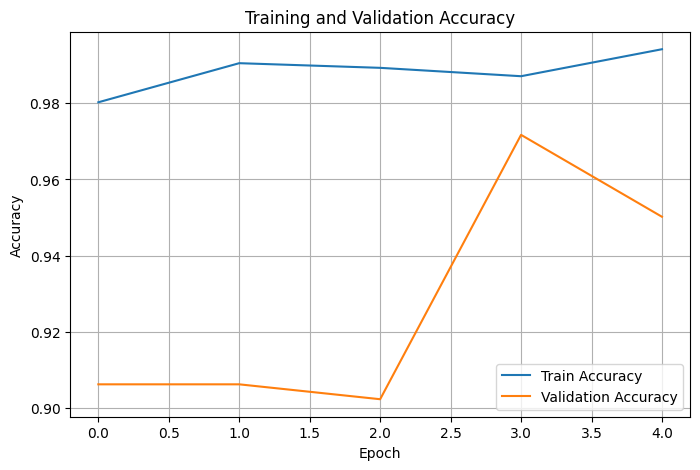

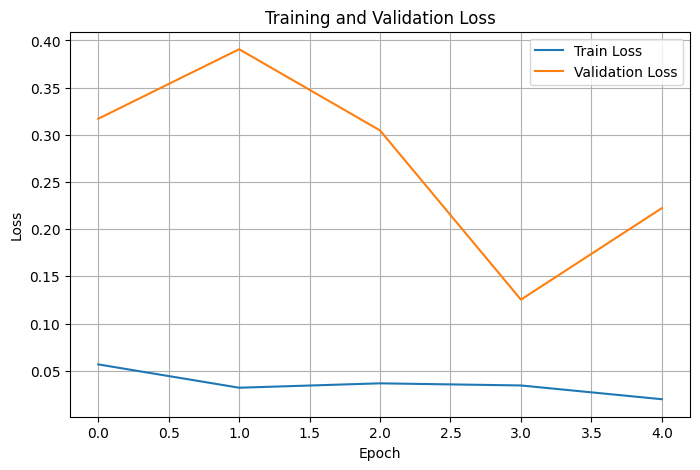

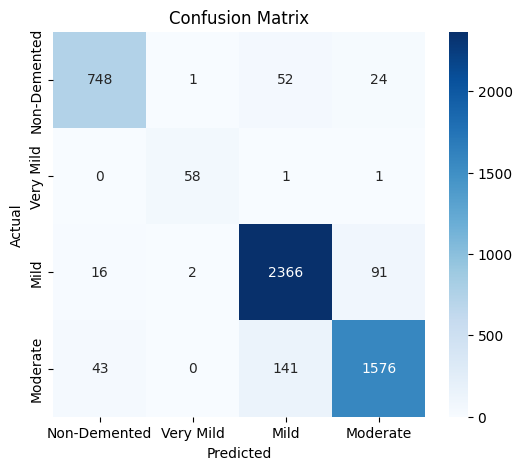

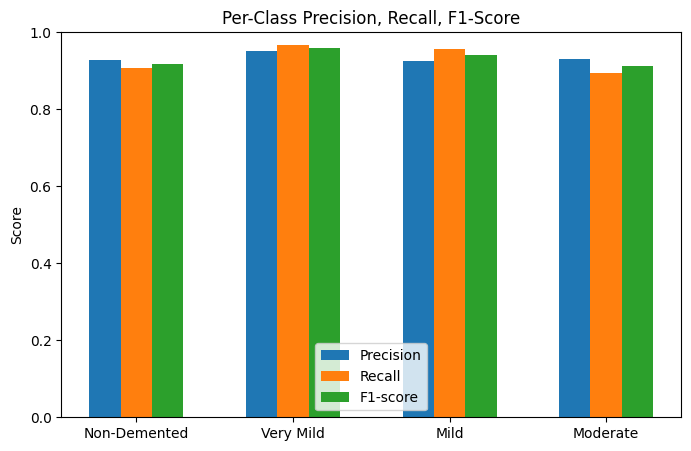

In [11]:
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import torch
import numpy as np
import seaborn as sns

# -----------------------------
# 1. Dataset Class Distribution
# -----------------------------
labels = [sample['label'] for sample in brain_dataset_train]  # adjust dataset variable
counts = Counter(labels)

plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color='skyblue')
plt.xticks(list(counts.keys()), ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented'], rotation=45)
plt.ylabel("Number of images")
plt.title("Dataset Class Distribution")
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Training/Validation Accuracy & Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# 3. Confusion Matrix
# -----------------------------
cm = confusion_matrix(all_labels, all_preds, labels=[0,1,2,3])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Non-Demented','Very Mild','Mild','Moderate'],
            yticklabels=['Non-Demented','Very Mild','Mild','Moderate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# -----------------------------
# 4. Per-Class Precision, Recall, F1-Score
# -----------------------------
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, labels=[0,1,2,3])
x = np.arange(4)
width = 0.2

plt.figure(figsize=(8,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')
plt.xticks(x, ['Non-Demented','Very Mild','Mild','Moderate'])
plt.ylabel("Score")
plt.ylim(0,1)
plt.title("Per-Class Precision, Recall, F1-Score")
plt.legend()
plt.show()





In [13]:
model.eval()
all_preds = []
all_labels = []
all_preds_proba = []

with torch.no_grad():
    for batch in test_dataloader:     # <-- FIXED HERE
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_preds_proba.extend(probs.cpu().numpy())


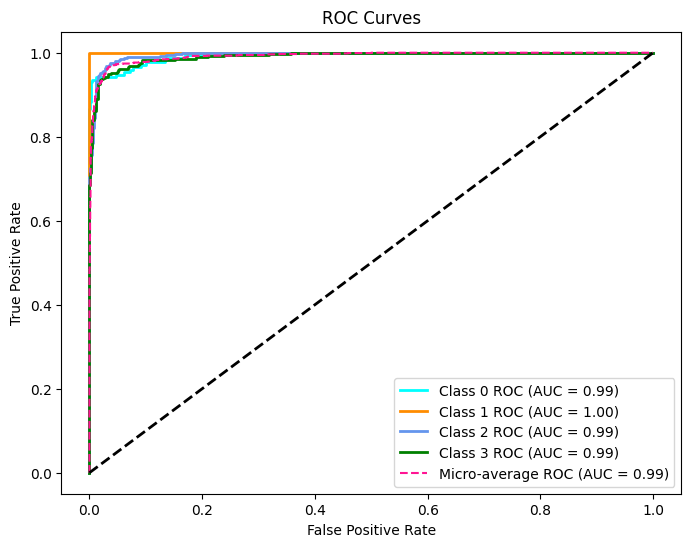

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import torch
import numpy as np
import matplotlib.pyplot as plt

n_classes = 4

# Binarize ground truth
y_test_bin = label_binarize(all_labels, classes=[0,1,2,3])

# Convert model outputs to probabilities (if not already done)
y_score = torch.nn.functional.softmax(torch.tensor(np.array(all_preds_proba)), dim=1).numpy()

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8,6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC (AUC = {roc_auc[i]:0.2f})')

plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle='--', label=f'Micro-average ROC (AUC = {roc_auc["micro"]:0.2f})')
plt.plot([0,1],[0,1],'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


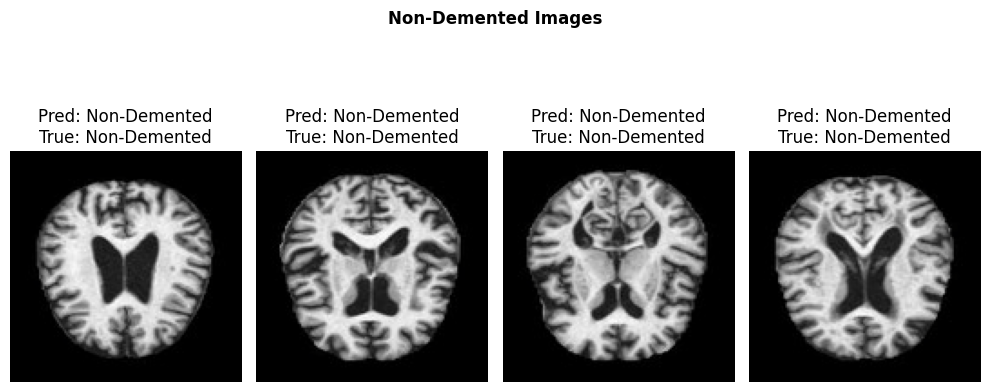

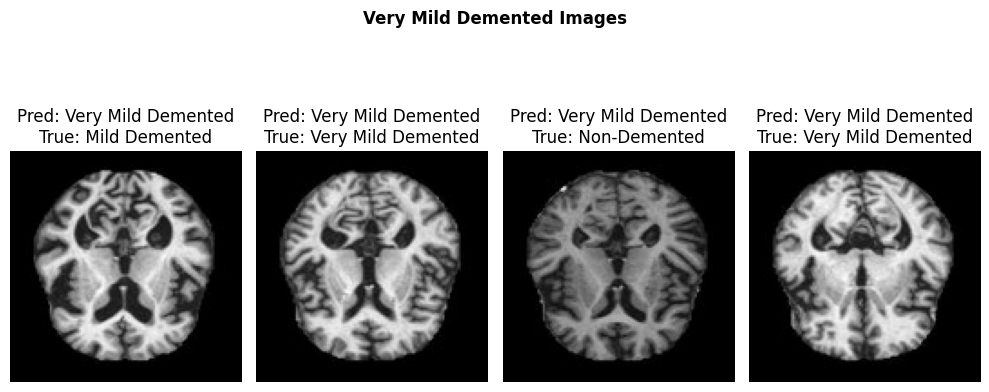

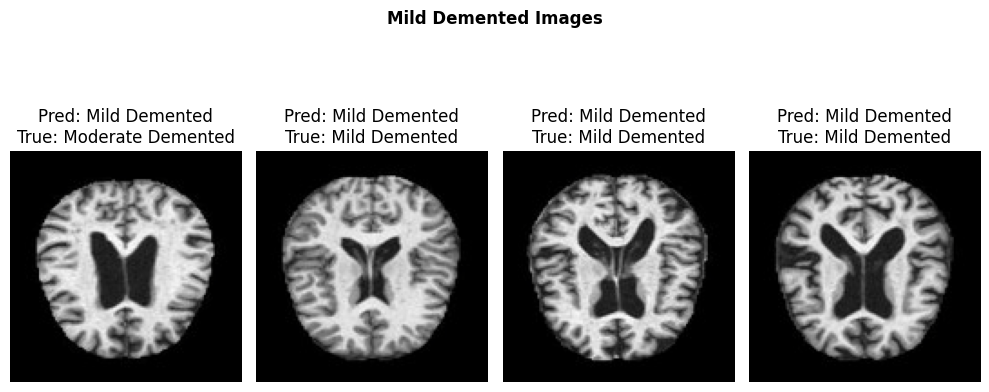

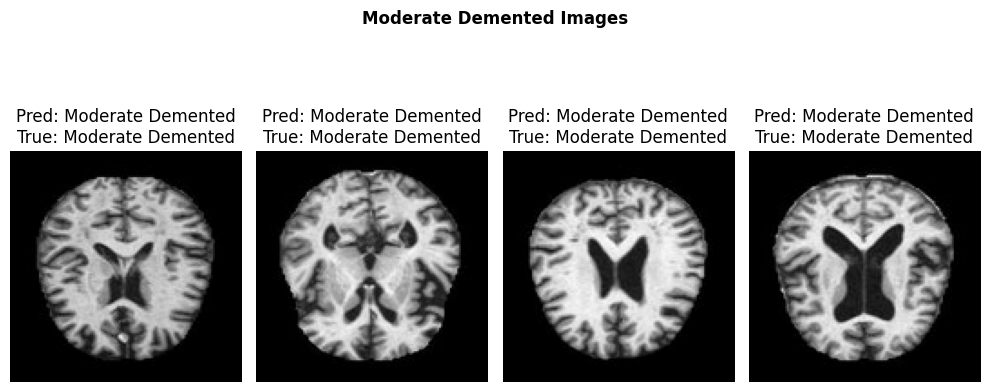

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Define MEAN and STD from your transforms
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

# Define class names corresponding to labels 0–3
class_names = ['Non-Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']

# --- Collect predictions, labels, probs, and images ---
model.eval()
all_preds = []
all_labels = []
all_preds_proba = []
test_images_collected = []

with torch.no_grad():
    for batch in test_dataloader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_preds_proba.extend(probs.cpu().numpy())
        test_images_collected.extend(images.cpu())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -------------------------------
# SHOW IMAGES FOR EACH PREDICTED CLASS (BY NAME)
# -------------------------------
unique_classes = np.unique(all_preds)

for cls in unique_classes:
    cls_name = class_names[cls]  # Map numeric ID to class name

    # Get indices where model predicted this class
    cls_indices = np.where(all_preds == cls)[0]

    # Show up to 4 examples
    sample_indices = cls_indices[:4]

    plt.figure(figsize=(10, 5))

    for i, idx in enumerate(sample_indices):
        plt.subplot(1, 4, i + 1)

        # --- Denormalize image ---
        img_tensor = test_images_collected[idx]
        img_numpy = img_tensor.permute(1, 2, 0).numpy()
        img_denorm = img_numpy * STD + MEAN
        img_denorm = np.clip(img_denorm, 0, 1)

        plt.imshow(img_denorm)
        plt.axis("off")
        plt.title(f"Pred: {class_names[all_preds[idx]]}\nTrue: {class_names[all_labels[idx]]}")

    plt.suptitle(f"{cls_name} Images", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
